# Notebook Conclusion

## Features Created

### Time-Based Features

- hour_of_day
- day_of_week
- day_name
- month
- week
- is_weekend

### Historical Demand Features

- lag_1
- lag_24
- lag_168

### Trend Features

- rolling_mean_24
- rolling_mean_168

---

## Why These Features Were Selected

The selected features capture the most important components of time-series forecasting:

### Temporal Patterns

Time-based features help the model understand when demand occurs.

### Historical Patterns

Lag features provide information about previous demand behavior.

### Trend Patterns

Rolling features help the model identify short-term and long-term demand trends.

---

## Correlation Analysis Findings

A correlation analysis was performed to evaluate relationships among the engineered features.

The strongest correlations with demand were observed for:

- lag_1 (0.95)
- lag_168 (0.91)
- lag_24 (0.88)

Rolling mean features also showed strong positive correlations with demand.

These results indicate that historical demand is the most important source of information for forecasting future demand.

Although several lag and rolling features are highly correlated with one another, this is expected because they are derived from the same demand time series and represent different temporal behaviors.

For example:

- lag_1 captures short-term demand patterns.
- lag_24 captures daily seasonality.
- lag_168 captures weekly seasonality.
- rolling_mean_24 captures recent demand trends.
- rolling_mean_168 captures long-term demand trends.

Since the forecasting models used in later stages will primarily be tree-based algorithms such as Random Forest, XGBoost, LightGBM, and CatBoost, these correlated features are retained for model evaluation and feature importance analysis.

---

## Dataset Status

The dataset has been:

- Cleaned
- Aggregated into hourly demand
- Feature engineered
- Validated
- Correlation analyzed

No critical data quality issues remain.

The dataset is ready for model development and forecasting.

---

## Next Step

Notebook 06: Baseline Forecasting and Model Development

In the next notebook, baseline forecasting models will be created and compared against machine learning approaches to establish performance benchmarks.

---
---


# NYC Taxi Demand Forecasting

## Notebook 05: Feature Engineering

---

## Objective

Create meaningful features that help forecasting models learn demand patterns.

---

## Why Feature Engineering?

Machine learning models cannot automatically understand time.

For example, a timestamp such as:

2026-01-15 08:00:00

does not directly tell the model that:

- It is morning rush hour.
- It is a weekday.
- It is similar to yesterday at 8 AM.
- It is similar to last week at 8 AM.

Feature engineering transforms raw timestamps into meaningful information that the model can learn from.

---

## Why Is This Important?

Demand forecasting is primarily driven by:

- Time patterns
- Historical demand patterns
- Daily seasonality
- Weekly seasonality

Without feature engineering, the model only sees numbers.

With feature engineering, the model sees behavior.

---

## Expected Outcome

By the end of this notebook:

- Time-based features will be created.
- Historical demand features will be created.
- Trend-based features will be created.
- The dataset will be ready for model training.

---
---

# Step 1: Load Demand Dataset

## Purpose

Load the hourly demand dataset created in the previous notebook.

## Description

This dataset contains the target variable that will be used for forecasting.

---

In [3]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)

df = pd.read_parquet(
    "/home/ed/Desktop/NYC_Taxi_Demand_Forecasting/Yellow_Dataset/data/hourly_demand.parquet"
)

print("Dataset loaded successfully.")

Dataset loaded successfully.


# Step 2:Dataset Overview

## Purpose

Verify the structure of the demand dataset before creating features.

## Description

Understanding the available columns helps identify which features can be engineered.

---

In [4]:
print(df.shape)

df.head()

(123602, 3)


,hour,PULocationID,demand
0,2025-12-31 23:00:00,113,1
1,2025-12-31 23:00:00,132,3
2,2025-12-31 23:00:00,163,1
3,2025-12-31 23:00:00,164,1
4,2026-01-01 00:00:00,3,2


# Step 3:Verify Created Features

## Purpose

Review newly created features.

## Description

Ensure that all extracted features are generated correctly.

---

In [5]:
df.head()

,hour,PULocationID,demand
0,2025-12-31 23:00:00,113,1
1,2025-12-31 23:00:00,132,3
2,2025-12-31 23:00:00,163,1
3,2025-12-31 23:00:00,164,1
4,2026-01-01 00:00:00,3,2


# Step 4:Time-Based Features

## Purpose

Extract useful information from the timestamp column.

## Why?

Human travel behavior follows time patterns.

For example:

- Morning hours often have high demand.
- Late-night hours usually have lower demand.
- Weekends behave differently from weekdays.

Creating these features helps the model learn these recurring patterns.

## Expected Outcome

New calendar-based features will be added.

---

In [6]:
df['hour_of_day'] = df['hour'].dt.hour

df['day_of_week'] = df['hour'].dt.dayofweek

df['day_name'] = df['hour'].dt.day_name()

df['month'] = df['hour'].dt.month

df['week'] = df['hour'].dt.isocalendar().week

df['is_weekend'] = (
    df['day_of_week']
    .isin([5, 6])
    .astype(int)
)

print("Time-based features created successfully.")

Time-based features created successfully.


## Conclusion

Time-based features provide contextual information about when demand occurs.

These features help the model capture daily and weekly seasonality.

---

# Step 5:Lag Features

## Purpose

Provide historical demand information to the model.

## Why?

Past demand is often the strongest predictor of future demand.

Lag features allow the model to learn from historical observations.

## Selected Lag Features

### lag_1

Demand during the previous hour.

Helps capture short-term demand behavior.

### lag_24

Demand during the same hour yesterday.

Helps capture daily seasonality.

### lag_168

Demand during the same hour last week.

Helps capture weekly seasonality.

These lag values are commonly used in real-world forecasting systems.

---

In [7]:
df = df.sort_values(
    ['PULocationID', 'hour']
)

df['lag_1'] = (
    df.groupby('PULocationID')['demand']
      .shift(1)
)

df['lag_24'] = (
    df.groupby('PULocationID')['demand']
      .shift(24)
)

df['lag_168'] = (
    df.groupby('PULocationID')['demand']
      .shift(168)
)

print("Lag features created successfully.")

Lag features created successfully.


## Conclusion

Lag features allow the model to learn temporal dependencies and recurring demand patterns.

---

# Step 6:Rolling Features

## Purpose

Capture recent demand trends.

## Why?

Demand may fluctuate from hour to hour.

Rolling averages smooth these fluctuations and reveal underlying patterns.

## Selected Features

### rolling_mean_24

Average demand during the previous 24 hours.

### rolling_mean_168

Average demand during the previous 7 days.

These features help the model understand short-term and long-term demand trends.

In [8]:
df['rolling_mean_24'] = (
    df.groupby('PULocationID')['demand']
      .transform(
          lambda x:x.shift(1)
          .rolling(24)
           .mean()
      )
)

df['rolling_mean_168'] = (
    df.groupby('PULocationID')['demand']
      .transform(
          lambda x:x.shift(1)
           .rolling(168)
           .mean()
      )
)

print("Rolling features created successfully.")

Rolling features created successfully.


## Conclusion

Rolling features help the model understand trend behavior and reduce the impact of short-term fluctuations.

---

# Step 7:Feature Review

## Purpose

Verify that all engineered features were created successfully.

## Description

Inspect the dataset structure after feature engineering.

In [9]:
df.head()

,hour,PULocationID,demand,hour_of_day,day_of_week,day_name,month,week,is_weekend,lag_1,lag_24,lag_168,rolling_mean_24,rolling_mean_168
426,2026-01-01 02:00:00,1,1,2,3,Thursday,1,1,0,NaN,NaN,NaN,NaN,NaN
839,2026-01-01 04:00:00,1,3,4,3,Thursday,1,1,0,1.0,NaN,NaN,NaN,NaN
1021,2026-01-01 05:00:00,1,5,5,3,Thursday,1,1,0,3.0,NaN,NaN,NaN,NaN
1200,2026-01-01 06:00:00,1,2,6,3,Thursday,1,1,0,5.0,NaN,NaN,NaN,NaN
1395,2026-01-01 07:00:00,1,2,7,3,Thursday,1,1,0,2.0,NaN,NaN,NaN,NaN


# Handle Lag-Induced Missing Values

## Purpose

Remove rows where lag and rolling features cannot be calculated.

## Description

The earliest observations do not have sufficient historical information.

These rows are removed before model training.



In [10]:
df = df.dropna()

print("Rows with lag-related missing values removed.")

Rows with lag-related missing values removed.


# Step 8:Missing Value Analysis

## Purpose

Identify missing values introduced during feature engineering.

## Description

Lag and rolling calculations require historical observations.

Therefore, the earliest records naturally contain missing values.

In [11]:
df.isnull().sum()

hour                0
PULocationID        0
demand              0
hour_of_day         0
day_of_week         0
day_name            0
month               0
week                0
is_weekend          0
lag_1               0
lag_24              0
lag_168             0
rolling_mean_24     0
rolling_mean_168    0
dtype: int64

## Conclusion

These missing values are a natural result of feature engineering and will be removed before model training.

---

# Step 9:Handle Missing Values

## Purpose

Remove records that lack sufficient historical information.

## Description

Forecasting models require complete feature values during training.

Rows containing lag-related missing values are removed.

---

In [12]:
df = df.dropna()

print("Rows with missing feature values removed.")

Rows with missing feature values removed.


## Observation

Missing values were introduced after creating lag and rolling features.

These missing values occur because the earliest observations do not have sufficient historical data available for feature calculation.

For example:

- lag_1 requires the previous hour.
- lag_24 requires the same hour from the previous day.
- lag_168 requires the same hour from the previous week.

Therefore, missing values at the beginning of the time series are expected.

## Conclusion

No imputation was performed for lag-related missing values.

Filling these values with zeros, averages, or other estimates would introduce artificial historical information and may negatively affect model learning.

Since these records represent only the initial observations where historical data is unavailable, they were removed before model training.

---

# Step 10:Feature Validation

## Purpose

Validate the engineered features before using them for model training.

## Description

Feature engineering can introduce unexpected values or errors.

Therefore, all created features should be inspected before proceeding to modeling.


In [13]:
print("Shape:", df.shape)

df.head()

Shape: (84740, 14)


,hour,PULocationID,demand,hour_of_day,day_of_week,day_name,month,week,is_weekend,lag_1,lag_24,lag_168,rolling_mean_24,rolling_mean_168
73763,2026-01-19 16:00:00,1,4,16,0,Monday,1,4,0,1.0,1.0,1.0,1.416667,1.827381
73924,2026-01-19 17:00:00,1,4,17,0,Monday,1,4,0,4.0,1.0,3.0,1.541667,1.845238
74265,2026-01-19 19:00:00,1,1,19,0,Monday,1,4,0,4.0,1.0,5.0,1.666667,1.851190
75618,2026-01-20 05:00:00,1,1,5,1,Tuesday,1,4,0,1.0,1.0,2.0,1.666667,1.827381
75994,2026-01-20 07:00:00,1,1,7,1,Tuesday,1,4,0,1.0,2.0,2.0,1.666667,1.821429


In [14]:
print("Information about the dataset:")
df.info()

Information about the dataset:
<class 'pandas.core.frame.DataFrame'>
Index: 84740 entries, 73763 to 123417
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   hour              84740 non-null  datetime64[us]
 1   PULocationID      84740 non-null  int32         
 2   demand            84740 non-null  int64         
 3   hour_of_day       84740 non-null  int32         
 4   day_of_week       84740 non-null  int32         
 5   day_name          84740 non-null  object        
 6   month             84740 non-null  int32         
 7   week              84740 non-null  UInt32        
 8   is_weekend        84740 non-null  int64         
 9   lag_1             84740 non-null  float64       
 10  lag_24            84740 non-null  float64       
 11  lag_168           84740 non-null  float64       
 12  rolling_mean_24   84740 non-null  float64       
 13  rolling_mean_168  84740 non-null  float64    

# Step 11:Feature Summary

## Purpose

Review statistical properties of engineered features.

## Description

Summary statistics help identify unexpected values and verify feature quality.



In [15]:
print("Descriptive statistics of the dataset:")
df.describe()

Descriptive statistics of the dataset:


,hour,PULocationID,demand,hour_of_day,day_of_week,month,week,is_weekend,lag_1,lag_24,lag_168,rolling_mean_24,rolling_mean_168
count,84740,84740.000000,84740.000000,84740.000000,84740.000000,84740.000000,84740.0,84740.000000,84740.000000,84740.000000,84740.000000,84740.000000,84740.000000
mean,2026-01-20 23:46:17.531272,139.724829,35.023318,11.975171,3.103564,1.000012,3.769707,0.289202,34.969129,34.657482,34.027000,34.799657,33.687176
min,2026-01-07 23:00:00,1.000000,1.000000,0.000000,0.000000,1.000000,2.0,0.000000,1.000000,1.000000,1.000000,1.000000,1.202381
25%,2026-01-15 12:00:00,74.000000,2.000000,7.000000,1.000000,1.000000,3.0,0.000000,2.000000,2.000000,2.000000,2.833333,2.744048
50%,2026-01-21 06:00:00,141.000000,6.000000,12.000000,3.000000,1.000000,4.0,0.000000,6.000000,6.000000,6.000000,6.833333,6.630952
75%,2026-01-26 20:00:00,211.000000,27.000000,18.000000,5.000000,1.000000,5.0,1.000000,26.000000,26.000000,26.000000,43.750000,47.410714
max,2026-02-01 00:00:00,265.000000,798.000000,23.000000,6.000000,2.000000,5.0,1.000000,798.000000,798.000000,798.000000,303.666667,250.988095
std,NaN,76.174821,70.694836,6.629635,1.920913,0.003435,0.99124,0.453395,70.638882,70.395538,68.761845,54.448387,50.666169


# Step 12:Final Dataset Validation

## Purpose

Ensure the dataset is ready for model training.

## Description

Machine learning models require complete and consistent feature values.



In [19]:
print("Missing Values:")
print(df.isnull().sum().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())


Missing Values:
0

Duplicate Rows:
0


In [23]:
try:
    df.to_parquet(
        "data/citywide_hourly_demand.parquet"
    )
    print("Data Saved Successfully")

except:

    print("Already saved")


Already saved


# Step 13:Feature Correlation Analysis

## Purpose

Evaluate relationships between engineered features.

## Description

Feature engineering can create variables that contain similar information.

Correlation analysis helps identify:

- Strongly related features
- Potential redundancy
- Multicollinearity risks

## Expected Outcome

Better understanding of relationships among engineered features.

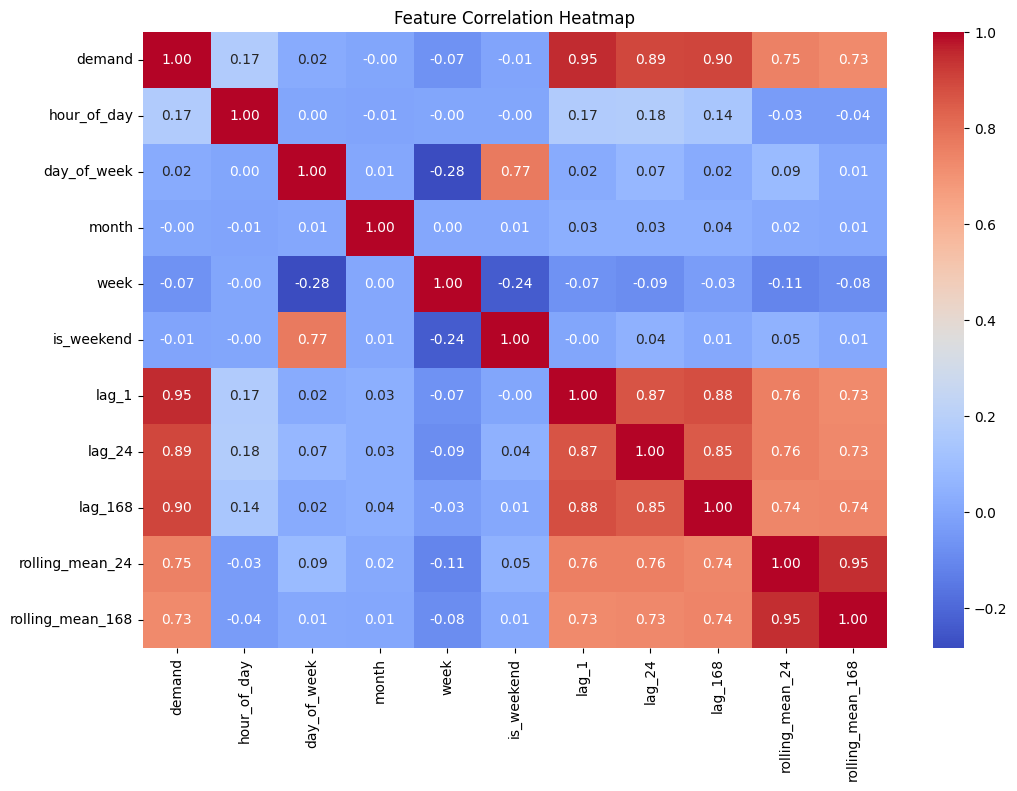

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
numeric_cols = [
    'demand',
    'hour_of_day',
    'day_of_week',
    'month',
    'week',
    'is_weekend',
    'lag_1',
    'lag_24',
    'lag_168',
    'rolling_mean_24',
    'rolling_mean_168'
]

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Feature Correlation Heatmap")

plt.show()

## Observation

The correlation heatmap shows strong positive relationships between demand and historical demand features.

The highest correlations are observed for:

- lag_1 (0.95)
- lag_168 (0.91)
- lag_24 (0.88)

Rolling mean features also show strong positive correlations with demand.

High correlations are expected because these features are derived from historical demand values and represent different temporal patterns.

Time-based features such as month, week, and weekend indicators show relatively weak correlations with demand, suggesting that historical demand is a stronger predictor than calendar information.

---

## Conclusion

Several engineered features exhibit high correlation with one another.

This behavior is expected in time-series forecasting because lag and rolling features are derived from the same demand sequence.

Although correlation is high, these features capture different aspects of demand behavior, including:

- Short-term patterns (lag_1)
- Daily seasonality (lag_24)
- Weekly seasonality (lag_168)
- Recent demand trends (rolling_mean_24)
- Long-term demand trends (rolling_mean_168)

Since the project will use tree-based machine learning models such as Random Forest, XGBoost, LightGBM, and CatBoost, multicollinearity is less problematic than in traditional linear regression models.

Therefore, all engineered features will be retained and their predictive importance will be evaluated during model training.

---
---

In [2]:
df.to_parquet(
    "/home/ed/Desktop/NYC_Taxi_Demand_Forecasting/Yellow_Dataset/data/feature_engineered_demand.parquet",
    index=False
)

print("Feature engineered dataset saved successfully.")

NameError: name 'df' is not defined

In [1]:
df.head()

NameError: name 'df' is not defined